# Classic models (MIDI) — vodič kroz notebook

Isti zadatak kao u `classic_models_raw.ipynb` — prepoznavanje kompozitora po djelu — ali atributi se ovdje
izvlače iz MusicNet-ovih note-level (MIDI) anotacija (`train_labels/`, `test_labels/`), ne iz audio signala.
Nikakav `.wav` se ne učita, pa je ovaj pipeline mnogo brži od audio verzije.

Isti metodološki okvir: `work_id` grupisanje, `StratifiedGroupKFold`, work-level majority vote, macro F1
kao glavna metrika (dataset je neuravnotežen po kompozitorima).

In [1]:
%load_ext autoreload
%autoreload 2

# Ucitavanje podataka

## Učitavanje i pregled metapodataka

`metadata` je tabela u kojoj svaki red opisuje jedan audio zapis / stav: kompozitora, djelo, stav, ansambl,
trajanje itd. Naredne ćelije prvo provjeravaju nedostajuće vrijednosti i spisak kompozitora, a tek onda
odlučuju koje klase ostaju u eksperimentu.

Putanje `AUDIO_DIR` i `METADATA_PATH` su lokalne putanje sa računara na kojem je notebook pisan; na drugom
računaru moraju da pokazuju na odgovarajuću lokaciju MusicNet fajlova.


In [2]:
import numpy as np
import pandas as pd

from paths import AUDIO_DIR, METADATA_PATH

metadata = pd.read_csv(METADATA_PATH)

print(metadata.head())
print(metadata.columns)

     id  composer               composition                   movement  \
0  1727  Schubert  Piano Quintet in A major                 2. Andante   
1  1728  Schubert  Piano Quintet in A major         3. Scherzo: Presto   
2  1729  Schubert  Piano Quintet in A major  4. Andantino - Allegretto   
3  1730  Schubert  Piano Quintet in A major          5. Allegro giusto   
4  1733  Schubert   Piano Sonata in A major               2. Andantino   

        ensemble            source                      transcriber  \
0  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
1  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
2  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
3  Piano Quintet  European Archive  http://tirolmusic.blogspot.com/   
4     Solo Piano          Museopen                Segundo G. Yogore   

  catalog_name  seconds  
0        OP114      447  
1        OP114      251  
2        OP114      444  
3        OP114      368 

In [3]:
metadata.isna().sum()
# No missing values

id              0
composer        0
composition     0
movement        0
ensemble        0
source          0
transcriber     0
catalog_name    0
seconds         0
dtype: int64

In [4]:
metadata["composer"].unique()
# We have 10 composers

<StringArray>
[ 'Schubert',    'Mozart',    'Dvorak',   'Cambini',     'Haydn',    'Brahms',
     'Faure',     'Ravel',      'Bach', 'Beethoven']
Length: 10, dtype: str

## Zašto se pravi `work_id`?

Jedno muzičko djelo može imati više stavova, a u metapodacima su oni posebni redovi. Kombinacijom
`composer + composition` pravi se identifikator cijelog djela. Tako npr. više stavova iste sonate ostaju ista
grupa tokom cross-validationa.

Nakon toga se broji broj **različitih djela po kompozitoru**, ne broj segmenata. Kompozitori sa manje od 5
djela se uklanjaju jer bi grupni cross-validation za njih bio vrlo nestabilan.


In [5]:
metadata["work_id"] = (
    metadata["composer"].astype(str)
    + " | "
    + metadata["composition"].astype(str)
)

# Adding a column so we can group the same composition from different movements

In [6]:
work_counts = (
    metadata.groupby("composer")["work_id"]
    .nunique()
)

print(work_counts)

# We will remove all the composers that have less than 5 compositions in the dataset, also we can see our dataset is inbalanced

composer
Bach         30
Beethoven    55
Brahms        8
Cambini       3
Dvorak        2
Faure         1
Haydn         1
Mozart       11
Ravel         1
Schubert      9
Name: work_id, dtype: int64


In [7]:
valid_composers = work_counts[
    work_counts >= 5
].index

metadata_filtered = metadata[
    metadata["composer"].isin(valid_composers)
].copy()

# Filtering the composers

In [8]:
metadata_filtered = metadata_filtered[metadata_filtered["composer"]!='Brahms']

In [9]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Group-aware evaluacija

Želimo da mjerimo generalizaciju na **nova djela**, ne na nove segmente poznatog djela. `StratifiedGroupKFold`
drži sve segmente istog `work_id` u istom foldu i približno čuva raspodjelu kompozitora po foldovima.

In [10]:
from sklearn import metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from evaluation import make_sample_weights, majority_vote_prediction

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

---

# MIDI model

Svaka nota u MusicNet anotacijama ima visinu, instrument, tačan onset/offset i trajanje u otkucajima.
`extract_midi_features` (u `midi.py`) iz toga računa gustinu nota, melodijski kontur (interval mean/std,
udio uzlaznih/silaznih/ponovljenih koraka), histogram tonskih klasa, histogram instrumenata (11 fiksnih GM
programa u MusicNet-u), on-beat/off-beat omjer i raspon akorada.

Napomena: `end_beat` kolona u MusicNet CSV-u je zapravo **trajanje note u otkucajima**, ne apsolutna
pozicija (provjereno — `end_beat < start_beat` za svaki red u fajlu).

In [11]:
from midi import make_midi_dataset

X_midi, y_midi, groups_midi = make_midi_dataset(metadata_filtered, AUDIO_DIR)

print(X_midi.shape)

Processing MIDI labels:  19%|█▉        | 54/278 [00:11<00:33,  6.67it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  20%|█▉        | 55/278 [00:12<00:30,  7.39it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  33%|███▎      | 93/278 [00:14<00:11, 16.28it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found

(9932, 56)


In [12]:
from itertools import product
import time

all_work_true_midi = []
all_work_pred_midi = []

results = []

param_grid = {
    "n_estimators": [300, 500], # models statistically improve with more estimators
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 3, 5]
}

grid_start_time = time.time()

for n_est, max_dp, min_slf in product(*param_grid.values()):

    work_acc_scores = []
    work_f1_scores = []
    work_auc_scores = []


    for train_idx, val_idx in sgkf.split(X_midi, y_midi, groups_midi):
        X_train_fold = X_midi[train_idx]
        y_train_fold = y_midi[train_idx]
        groups_train = groups_midi[train_idx]

        X_val_fold = X_midi[val_idx]
        y_val_fold = y_midi[val_idx]
        groups_val = groups_midi[val_idx]

        sample_weights = make_sample_weights(y_train_fold, groups_train)

        model = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_dp,
            min_samples_leaf=min_slf,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

        pred = model.predict(X_val_fold)

        work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

        work_accuracy = metrics.accuracy_score(
            work_true,
            work_pred
        )

        work_f1 = metrics.f1_score(
            work_true,
            work_pred,
            average = "macro"
        )

        # work_auc = metrics.roc_auc_score(
        #     work_true,
        #     work_pred,
        #     average = "macro",
        #     multi_class = "ovo"
        # )
        work_auc = 0.0

        work_acc_scores.append(work_accuracy)
        work_f1_scores.append(work_f1)
        work_auc_scores.append(work_auc)


        all_work_true_midi.extend(work_true)
        all_work_pred_midi.extend(work_pred)


    mean_acc = np.mean(work_acc_scores)
    mean_f1 = np.mean(work_f1_scores)
    mean_auc = np.mean(work_auc_scores)

    results.append(
        (n_est, max_dp, min_slf, mean_acc, mean_f1, mean_auc)
    )

    print(
        f"n_est={n_est}, max_depth={max_dp}, min_sample_leaf={min_slf}: "
        f"accuracy={mean_acc:.4f}, "
        f"macro_f1={mean_f1:.4f}"
        # f"macro_auc={mean_auc:.4f}"
    )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nRandom Forest grid search "
    f"trajao: {grid_elapsed:.1f}s"
)


n_est=300, max_depth=10, min_sample_leaf=1: accuracy=0.8194, macro_f1=0.7473
n_est=300, max_depth=10, min_sample_leaf=3: accuracy=0.8194, macro_f1=0.7520
n_est=300, max_depth=10, min_sample_leaf=5: accuracy=0.8289, macro_f1=0.7601
n_est=300, max_depth=20, min_sample_leaf=1: accuracy=0.8671, macro_f1=0.7702
n_est=300, max_depth=20, min_sample_leaf=3: accuracy=0.8766, macro_f1=0.7725
n_est=300, max_depth=20, min_sample_leaf=5: accuracy=0.8580, macro_f1=0.7870
n_est=500, max_depth=10, min_sample_leaf=1: accuracy=0.8194, macro_f1=0.7540
n_est=500, max_depth=10, min_sample_leaf=3: accuracy=0.8294, macro_f1=0.7631
n_est=500, max_depth=10, min_sample_leaf=5: accuracy=0.8194, macro_f1=0.7540
n_est=500, max_depth=20, min_sample_leaf=1: accuracy=0.8766, macro_f1=0.7725
n_est=500, max_depth=20, min_sample_leaf=3: accuracy=0.8766, macro_f1=0.7767
n_est=500, max_depth=20, min_sample_leaf=5: accuracy=0.8580, macro_f1=0.7870

Random Forest grid search trajao: 111.6s


In [13]:
def get_max(results):
    max_acc = max([x[3] for x in results])
    max_f1 = max([x[4] for x in results])

    ths = [0.01, 0.05, 0.1, 0.2]
    for th in ths:
        new_results = [res for res in results if (res[3] > (1-th) * max_acc) and (res[4] > (1-th) * max_f1)]

        if new_results != []:
            results = new_results
            break

    return max(results, key=lambda x : x[4])
    


best = get_max(results)

print("\nBest n_estimators:", best[0])
print("Best max_depth:", best[1])
print("Best min_sample_leaf:", best[2])
print("Best accuracy:", best[3])
print("Best macro F1:", best[4])


Best n_estimators: 300
Best max_depth: 20
Best min_sample_leaf: 5
Best accuracy: 0.8579653679653679
Best macro F1: 0.7870252211556558


In [14]:
n_est, max_dp, min_slf = best[0], best[1], best[2]

all_work_true = []
all_work_pred = []

work_acc_scores = []
work_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_midi, y_midi, groups_midi),
    start = 1
):
    X_train_fold = X_midi[train_idx]
    y_train_fold = y_midi[train_idx]
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_dp,
        min_samples_leaf=min_slf,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        sample_weight=sample_weights
    )

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    work_accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    work_f1 = metrics.f1_score(
        work_true,
        work_pred,
        average = "macro"
    )

    work_acc_scores.append(work_accuracy)
    work_f1_scores.append(work_f1)

mean_acc = np.mean(work_acc_scores)
mean_f1 = np.mean(work_f1_scores)

grid_elapsed = time.time() - grid_start_time

In [15]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.87      0.93        30
   Beethoven       0.86      0.91      0.88        55
      Mozart       0.57      0.73      0.64        11
    Schubert       0.86      0.67      0.75         9

    accuracy                           0.86       105
   macro avg       0.82      0.79      0.80       105
weighted avg       0.87      0.86      0.86       105

Overall work accuracy: 0.8571428571428571
Overall work macro F1: 0.8008817951959545


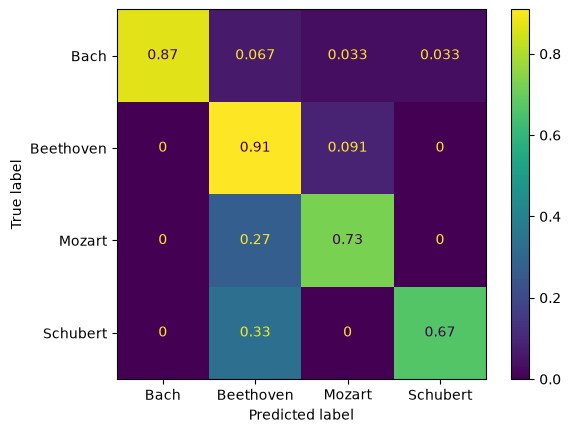

In [16]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

## ------ SVM Model -------------------------------------- 

In [17]:
import time
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

C_values = [10 ** i for i in range(-1, 3)]
gamma_values = [0.001, 0.005, 0.01, 0.1]

results = []

grid_start_time = time.time()

for C in C_values:
    for gamma in gamma_values:

        work_acc_scores = []
        work_f1_scores = []

        for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X_midi, y_midi, groups_midi),
            start = 1
        ):
            X_train_fold = X_midi[train_idx]
            y_train_fold = y_midi[train_idx]
            groups_train = groups_midi[train_idx]

            X_val_fold = X_midi[val_idx]
            y_val_fold = y_midi[val_idx]
            groups_val = groups_midi[val_idx]

            sample_weights = make_sample_weights(
                y_train_fold,
                groups_train
            )

            model = make_pipeline(
                preprocessing.StandardScaler(),

                SVC(
                    kernel = 'rbf',
                    C = C,
                    gamma = gamma,
                    class_weight = None
                )
            )

            model.fit(
                X_train_fold,
                y_train_fold,
                svc__sample_weight = sample_weights
            )

            pred = model.predict(X_val_fold)

            work_true, work_pred = majority_vote_prediction(
                y_val_fold,
                pred,
                groups_val
            )

            work_accuracy = metrics.accuracy_score(
                work_true,
                work_pred
            )

            work_f1 = metrics.f1_score(
                work_true,
                work_pred,
                average = "macro"
            )

            work_acc_scores.append(work_accuracy)
            work_f1_scores.append(work_f1)

        mean_acc = np.mean(work_acc_scores)
        mean_f1 = np.mean(work_f1_scores)

        results.append(
            (C,gamma,mean_acc,mean_f1)
        )

        print(
            f"C={C}, gamma={gamma}: "
            f"accuracy={mean_acc:.4f}, "
            f"macro_f1={mean_f1:.4f}"
        )

grid_elapsed = time.time() - grid_start_time
print(
    f"\nSVM grid search ({len(C_values)} C values x {len(gamma_values)} gamma values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)

C=0.1, gamma=0.001: accuracy=0.6868, macro_f1=0.6416
C=0.1, gamma=0.005: accuracy=0.7626, macro_f1=0.7184
C=0.1, gamma=0.01: accuracy=0.7912, macro_f1=0.7444
C=0.1, gamma=0.1: accuracy=0.6786, macro_f1=0.4468
C=1, gamma=0.001: accuracy=0.7722, macro_f1=0.7303
C=1, gamma=0.005: accuracy=0.8007, macro_f1=0.7614
C=1, gamma=0.01: accuracy=0.8194, macro_f1=0.7504
C=1, gamma=0.1: accuracy=0.6768, macro_f1=0.3599
C=10, gamma=0.001: accuracy=0.8389, macro_f1=0.8045
C=10, gamma=0.005: accuracy=0.8290, macro_f1=0.7583
C=10, gamma=0.01: accuracy=0.8480, macro_f1=0.7595
C=10, gamma=0.1: accuracy=0.6768, macro_f1=0.3599
C=100, gamma=0.001: accuracy=0.8285, macro_f1=0.7594
C=100, gamma=0.005: accuracy=0.8294, macro_f1=0.7183
C=100, gamma=0.01: accuracy=0.7912, macro_f1=0.6500
C=100, gamma=0.1: accuracy=0.6768, macro_f1=0.3599

SVM grid search (4 C values x 4 gamma values x 5 folds) trajao: 243.8s


In [18]:
best = max(
    results,
    key=lambda x: x[3]
)

print("\nBest C:", best[0])
print("Best gamma:", best[1])
print("Best accuracy:", best[2])
print("Best macro F1:", best[3])


Best C: 10
Best gamma: 0.001
Best accuracy: 0.8388744588744588
Best macro F1: 0.804541292041292


In [19]:
C, gamma = best[0], best[1]

all_work_true = []
all_work_pred = []

work_acc_scores = []
work_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(X_midi, y_midi, groups_midi),
    start = 1
):
    X_train_fold = X_midi[train_idx]
    y_train_fold = y_midi[train_idx]
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(
        y_train_fold,
        groups_train
    )

    model = make_pipeline(
        preprocessing.StandardScaler(),

        SVC(
            kernel = 'rbf',
            C = C,
            gamma = gamma,
            class_weight = None
        )
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        svc__sample_weight = sample_weights
    )

    pred = model.predict(X_val_fold)

    work_true, work_pred = majority_vote_prediction(
        y_val_fold,
        pred,
        groups_val
    )

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    work_accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    work_f1 = metrics.f1_score(
        work_true,
        work_pred,
        average = "macro"
    )

    work_acc_scores.append(work_accuracy)
    work_f1_scores.append(work_f1)

mean_acc = np.mean(work_acc_scores)
mean_f1 = np.mean(work_f1_scores)

grid_elapsed = time.time() - grid_start_time
print(
    f"\nSVM grid search ({len(C_values)} C values x {len(gamma_values)} gamma values x 5 folds) "
    f"trajao: {grid_elapsed:.1f}s"
)


SVM grid search (4 C values x 4 gamma values x 5 folds) trajao: 254.5s


In [20]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

              precision    recall  f1-score   support

        Bach       1.00      0.93      0.97        30
   Beethoven       0.92      0.80      0.85        55
      Mozart       0.41      0.82      0.55        11
    Schubert       1.00      0.78      0.88         9

    accuracy                           0.84       105
   macro avg       0.83      0.83      0.81       105
weighted avg       0.89      0.84      0.86       105

Overall work accuracy: 0.8380952380952381
Overall work macro F1: 0.8100851797181727


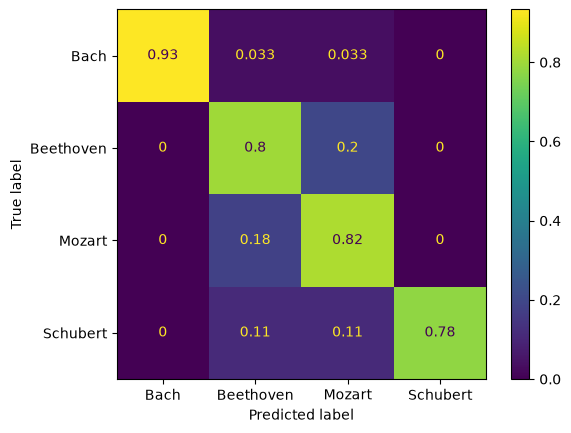

In [21]:
from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

In [22]:
import random 

def get_random_search_params(param_distributions, count):

    samples = []
    for _ in range(count):
        sample = {param: random.choice(vals) for param, vals in param_distributions.items()}
        samples.append(sample)
    return samples

def get_grid_search_params(param_distributions):

    return [
        {hp: p[i] 
            for i, hp in enumerate(param_distributions)} 
            for p in product(*param_distributions.values())
        ]

In [23]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_midi)

all_work_true = []
all_work_pred = []

param_distributions = {
    "n_estimators": [300, 500, 600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.005, 0.01, 0.03, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 2, 3, 5, 10, 15],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.1, 1.0],
    "reg_lambda": [1.0, 3.0, 5.0, 10.0],
    "gamma": [0, 0.1, 0.5, 1.0],
}


params_list = get_random_search_params(param_distributions, count=40)
results = []

for params in params_list:

    work_acc_scores = []
    work_f1_scores = []

    for train_idx, val_idx in sgkf.split(X_midi, y_midi, groups_midi):
        X_train_fold = X_midi[train_idx]
        y_train_fold = le.transform(y_midi[train_idx])
        groups_train = groups_midi[train_idx]

        X_val_fold = X_midi[val_idx]
        y_val_fold = y_midi[val_idx]
        groups_val = groups_midi[val_idx]

        sample_weights = make_sample_weights(y_midi[train_idx], groups_train)

        model = XGBClassifier(
            # n_estimators=300,
            # max_depth=20,
            # learning_rate=0.1,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

        pred = le.inverse_transform(model.predict(X_val_fold))

        work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

        work_accuracy = metrics.accuracy_score(
            work_true,
            work_pred,
        )

        work_f1 = metrics.f1_score(
            work_true,
            work_pred,
            average="macro"
        )

        work_acc_scores.append(work_accuracy)
        work_f1_scores.append(work_f1)

        all_work_true.extend(work_true)
        all_work_pred.extend(work_pred)


    mean_acc = np.mean(work_acc_scores)
    mean_f1 = np.mean(work_f1_scores)

    results.append(
        (mean_acc, mean_f1)
    )

    print(
        ", ".join([f"{param}={val:.4f}" for param, val in params.items()]) +
        f": accuracy={mean_acc:.4f}, "
        f"macro_f1={mean_f1:.4f}"
    )



# print(metrics.classification_report(all_work_true, all_work_pred))

n_estimators=600.0000, max_depth=4.0000, learning_rate=0.0050, min_child_weight=10.0000, subsample=0.6000, colsample_bytree=1.0000, reg_alpha=0.1000, reg_lambda=10.0000, gamma=0.0000: accuracy=0.8202, macro_f1=0.7575
n_estimators=500.0000, max_depth=4.0000, learning_rate=0.0050, min_child_weight=2.0000, subsample=0.9000, colsample_bytree=0.6000, reg_alpha=0.0000, reg_lambda=10.0000, gamma=1.0000: accuracy=0.8012, macro_f1=0.7489
n_estimators=500.0000, max_depth=3.0000, learning_rate=0.1000, min_child_weight=10.0000, subsample=1.0000, colsample_bytree=0.9000, reg_alpha=0.1000, reg_lambda=3.0000, gamma=0.5000: accuracy=0.8956, macro_f1=0.7940
n_estimators=300.0000, max_depth=6.0000, learning_rate=0.0100, min_child_weight=3.0000, subsample=1.0000, colsample_bytree=1.0000, reg_alpha=0.0000, reg_lambda=3.0000, gamma=0.1000: accuracy=0.8588, macro_f1=0.7765
n_estimators=300.0000, max_depth=2.0000, learning_rate=0.1000, min_child_weight=10.0000, subsample=0.9000, colsample_bytree=0.6000, reg_

In [24]:
def get_max(results):
    acc_idx, f1_idx = 0, 1

    results = list(enumerate(results))
    max_acc = max([x[1][acc_idx] for x in results])
    max_f1 = max([x[1][f1_idx] for x in results])

    ths = [0.01, 0.05, 0.1, 0.2]
    for th in ths:
        new_results = [res for res in results if (res[1][acc_idx] > (1-th) * max_acc) and (res[1][f1_idx] > (1-th) * max_f1)]

        if new_results != []:
            results = new_results
            break

    return max(results, key=lambda x: (x[1][f1_idx]).item())
    


max_ = get_max(results)
best_idx = max_[0]
best_acc = max_[1][0]
best_f1 = max_[1][1]
best_params = params_list[best_idx]

print("Best params: ", best_params)
print("Best accuracy:", best_acc)
print("Best macro F1:", best_f1)

Best params:  {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'min_child_weight': 3, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0, 'reg_lambda': 1.0, 'gamma': 1.0}
Best accuracy: 0.8956277056277056
Best macro F1: 0.8099986607595303


In [25]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_midi)

all_work_true = []
all_work_pred = []

for train_idx, val_idx in sgkf.split(X_midi, y_midi, groups_midi):
    X_train_fold = X_midi[train_idx]
    y_train_fold = le.transform(y_midi[train_idx])
    groups_train = groups_midi[train_idx]

    X_val_fold = X_midi[val_idx]
    y_val_fold = y_midi[val_idx]
    groups_val = groups_midi[val_idx]

    sample_weights = make_sample_weights(y_midi[train_idx], groups_train)

    model = XGBClassifier(
        # n_estimators=300,
        # max_depth=20,
        # learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        **best_params
    )

    model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights)

    pred = le.inverse_transform(model.predict(X_val_fold))

    work_true, work_pred = majority_vote_prediction(y_val_fold, pred, groups_val)

    work_accuracy = metrics.accuracy_score(
        work_true,
        work_pred,
    )

    work_f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    work_acc_scores.append(work_accuracy)
    work_f1_scores.append(work_f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

mean_acc = np.mean(work_acc_scores)
mean_f1 = np.mean(work_f1_scores)


# print(metrics.classification_report(all_work_true, all_work_pred))

              precision    recall  f1-score   support

        Bach       1.00      0.93      0.97        30
   Beethoven       0.91      0.95      0.93        55
      Mozart       0.57      0.73      0.64        11
    Schubert       1.00      0.67      0.80         9

    accuracy                           0.90       105
   macro avg       0.87      0.82      0.83       105
weighted avg       0.91      0.90      0.90       105

Overall work accuracy: 0.8952380952380953
Overall work macro F1: 0.8335221674876847


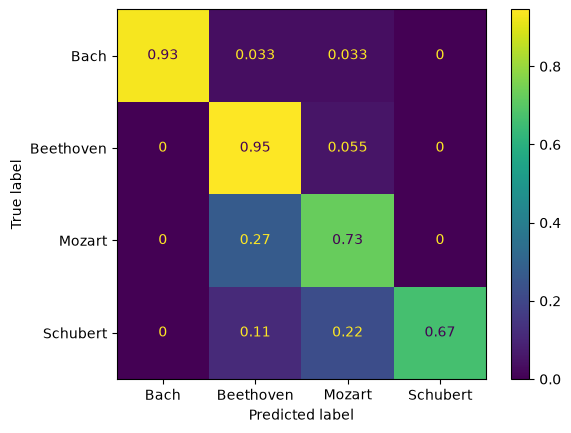

In [26]:
print(
    metrics.classification_report(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work accuracy:",
    metrics.accuracy_score(
        all_work_true,
        all_work_pred
    )
)

print(
    "Overall work macro F1:",
    metrics.f1_score(
        all_work_true,
        all_work_pred,
        average = "macro"
    )
)

from matplotlib import pyplot as plt

metrics.ConfusionMatrixDisplay.from_predictions(
    all_work_true,
    all_work_pred,
    normalize="true"
)

plt.show()